# Aula 09: Treinando seu Próprio Detector (Custom Training) 🏋️‍♂️

Neste notebook, vamos realizar o treinamento de um modelo YOLO em um dataset customizado (ex: `dataset_aquarium`).

Certifique-se de que você extraiu o dataset na pasta apropriada e que o arquivo `data.yaml` está acessível.

## 1. Verificando a Estrutura do Dataset

Vamos garantir que as bibliotecas e diretórios estão corretos.

In [1]:
import os
from ultralytics import YOLO, settings

# Opcional: configurar o diretório base para runs
settings.update({'runs_dir': './runs'})

dataset_yaml = '../dataset_aquarium/data.yaml'

if os.path.exists(dataset_yaml):
    print(f"Arquivo encontrado: {dataset_yaml}")
else:
    print(f"Arquivo NÃO encontrado: {dataset_yaml}. Ajuste o caminho ou baixe o dataset.")

Arquivo encontrado: ../dataset_aquarium/data.yaml


## 2. Inicializando o Modelo e Treinando

Nós começamos com um modelo pré-treinado (`yolov8n.pt`) e ensinamos as novas classes a ele passando o nosso `data.yaml`.

*   `data`: Onde estão as imagens.
*   `epochs`: Quantas vezes o modelo vai estudar todo o dataset. (Recomendado: 50+, para teste use 5).
*   `imgsz`: Tamanho da imagem (640 é padrão).

In [2]:
model = YOLO('yolov8n.pt')

# Rodando o treinamento por 5 épocas
# Nota: Para um resultado robusto, você usaria algo como epochs=50 ou 100.
# results = model.train(data=dataset_yaml, epochs=5, imgsz=640)

# Se a CUDA travar por falta de memória:=> Altere batch=2 (duas imagens por vez) e reduzindo a resolução para 416
results = model.train(data=dataset_yaml, epochs=5, imgsz=416, batch=2)

# Nota: Se ainda assim o erro persistir por falta de memória na placa de vídeo do notebook, 
# você pode forçar o treinamento a rodar usando o processador da máquina (CPU), que é mais lento, mas não tem o limite de 2GB. 
# Bastaria adicionar device='cpu' dentro dos parênteses do model.train().
# Tente com batch=2 primeiro para aproveitar a placa de vídeo!

Ultralytics 8.4.14 🚀 Python-3.12.1 torch-2.7.1+cu126 CUDA:0 (NVIDIA GeForce GTX 960M, 2048MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset_aquarium/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, 

## 3. Analisando os Resultados 📊

Após o término do treino, os resultados serão salvos na pasta `runs/detect/train`.
Uma forma fácil de verificar é observar o lote de validação ou a curva de aprendizado.

Analisando resultados da pasta: runs/detect/train4
Amostra de Validação:


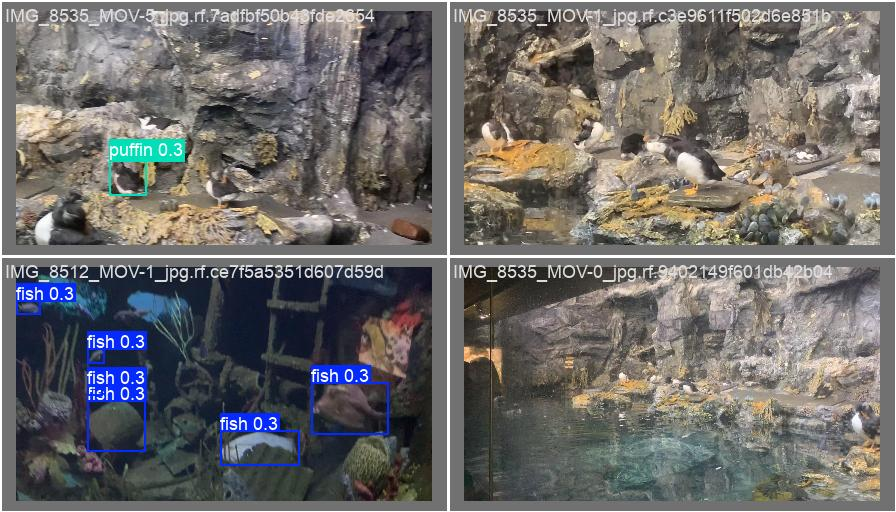


Gráficos de Treinamento:


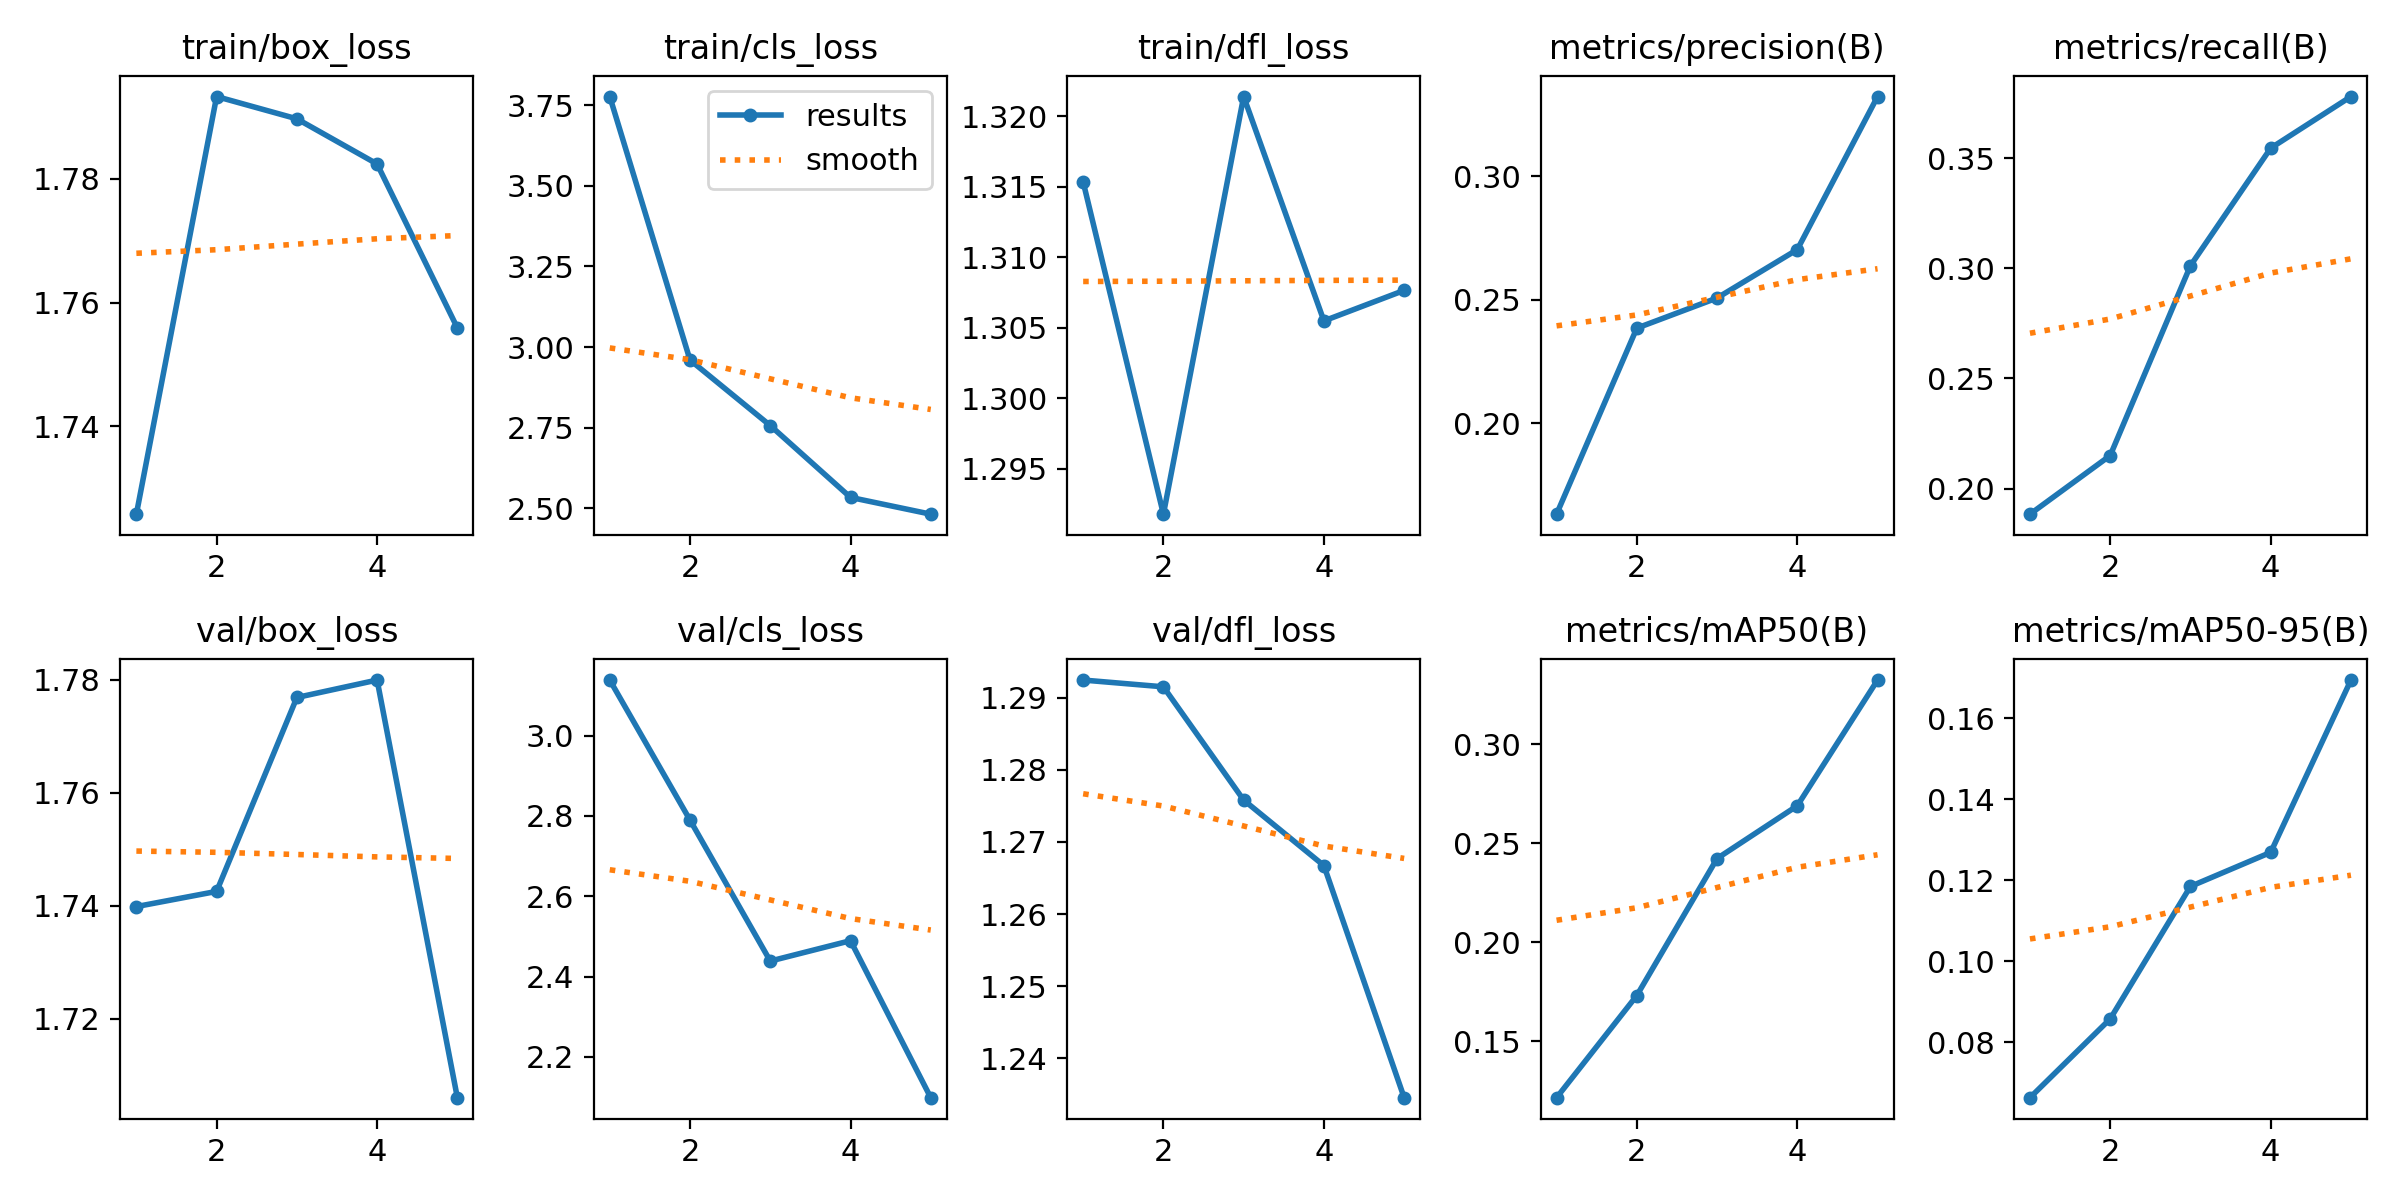

In [3]:
from IPython.display import Image, display
import glob

# Pegando a última pasta de treino criada:
list_of_runs = glob.glob('runs/detect/train*')
latest_run = max(list_of_runs, key=os.path.getctime) if list_of_runs else None

if latest_run:
    print(f"Analisando resultados da pasta: {latest_run}")
    
    # Mostrar as predições em um lote de validação
    val_img = os.path.join(latest_run, 'val_batch0_pred.jpg')
    if os.path.exists(val_img):
        print("Amostra de Validação:")
        display(Image(filename=val_img, width=800))
        
    # Mostrar o gráfico de resultados (loss, mapa)
    results_img = os.path.join(latest_run, 'results.png')
    if os.path.exists(results_img):
        print("\nGráficos de Treinamento:")
        display(Image(filename=results_img, width=800))
else:
    print("Nenhum resultado de treino encontrado ainda.")